# Model Review & Validation Framework

## Why this model review was built

In production risk and structured-finance environments, model outputs cannot be used directly for
pricing, risk reporting, or client delivery without **independent validation and monitoring**.
Even well-designed models can produce misleading results due to data issues, calibration drift,
or unintended behavioural changes.

The purpose of this notebook is to implement an **automated model review and validation framework**
that evaluates whether prepayment and credit model outputs are:
- internally consistent,
- economically intuitive,
- stable across runs, and
- safe to consume for downstream valuation and risk decisions.

This reflects real-world workflows used by **risk management, model governance, and client analytics teams**.

---

## What the notebook does

### 1. Input: Model Outputs and Risk Drivers
The notebook ingests model outputs at the loan level, including:
- Prepayment rates (CPR)
- Default measures (PD, MDR)
- Loss Given Default (LGD)
- Key risk drivers such as FICO, LTV, and DTI

These are treated as *model outputs to be reviewed*, not as raw data to be modeled.

---

### 2. Data Quality Validation
The first layer of review checks for:
- Missing values
- Values outside economically meaningful ranges
- Structural inconsistencies (e.g. negative rates, implausible LGDs)

**Objective:** ensure the data is technically usable before interpreting any results.

---

### 3. Economic Sanity Checks (Monotonicity)
The notebook tests whether credit risk behaves as expected across core dimensions:

- **PD vs FICO:**  
  Default probability should decrease as borrower credit quality improves.

- **PD vs LTV:**  
  Default probability should increase as borrower leverage rises.

These relationships are evaluated using bucketed averages and monotonicity diagnostics.

**Objective:** confirm that the model encodes economically correct risk relationships.

---

### 4. Stability & Drift Detection
Model outputs from the current run are compared against a prior run to detect:
- changes in average CPR, PD, MDR, and LGD,
- statistically significant shifts using z-score–based drift measures.

**Objective:** identify silent model or data changes that could impact valuation or risk metrics.

---

### 5. Issue Consolidation & Reporting
All detected problems — data quality flags, monotonicity violations, or drift breaches — are
consolidated into a single **Issues table**.

The notebook then exports:
- Excel reports for analyst review,
- HTML summaries for quick stakeholder communication,
- configuration snapshots for audit and reproducibility.

---

In [1]:
import os
import json
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
@dataclass(frozen=True)
class ReviewConfig:
    client_name: str = "DemoClient"
    run_date: str = "2026-01-24"
    out_dir: str = "review_outputs"
    # Validation thresholds
    max_missing_pct: float = 0.01
    cpr_max: float = 0.60
    mdr_max: float = 0.20
    pd_monotonic_tolerance: float = 0.02  # allow small violations due to noise
    drift_z_threshold: float = 3.0
    # Bucketing
    fico_bins: tuple = (580, 620, 660, 700, 740, 780, 820)
    ltv_bins: tuple  = (0.50, 0.60, 0.70, 0.80, 0.90, 1.10)

cfg = ReviewConfig()
cfg

ReviewConfig(client_name='DemoClient', run_date='2026-01-24', out_dir='review_outputs', max_missing_pct=0.01, cpr_max=0.6, mdr_max=0.2, pd_monotonic_tolerance=0.02, drift_z_threshold=3.0, fico_bins=(580, 620, 660, 700, 740, 780, 820), ltv_bins=(0.5, 0.6, 0.7, 0.8, 0.9, 1.1))

In [4]:
def make_demo_data(n=200000, seed=7):
    rng = np.random.default_rng(seed)

    fico = rng.integers(580, 820, size=n)
    ltv = np.clip(rng.normal(0.78, 0.10, size=n), 0.45, 1.10)
    dti = np.clip(rng.normal(0.33, 0.08, size=n), 0.05, 0.70)

    # “Model outputs”
    # PD higher for low FICO, high LTV, high DTI
    pd_annual = (
        0.005
        * np.exp((720 - fico) / 120)
        * np.exp((ltv - 0.75) * 2.5)
        * np.exp((dti - 0.30) * 1.5)
    )
    pd_annual = np.clip(pd_annual, 0.0005, 0.25)

    # MDR (monthly hazard)
    mdr = 1 - (1 - pd_annual) ** (1/12)

    # CPR: baseline + seasoning proxy (random) + rate incentive proxy (random)
    seasoning = np.clip(rng.normal(0.8, 0.2, size=n), 0.0, 1.0)
    incentive = np.clip(rng.normal(0.02, 0.015, size=n), 0.0, 0.10)
    cpr = np.clip(0.03 * seasoning + 0.25 * (1 - np.exp(-6 * incentive)), 0.0, 0.65)

    df = pd.DataFrame({
        "loan_id": np.arange(n),
        "fico": fico,
        "ltv": ltv,
        "dti": dti,
        "cpr": cpr,
        "mdr": mdr,
        "pd_annual": pd_annual,
        "lgd": np.clip(rng.normal(0.35, 0.08, size=n), 0.05, 0.80),
        "run_id": "current"
    })

    # create a “prior run” for drift comparison
    df_prev = df.copy()
    df_prev["run_id"] = "prior"
    # small drift
    df_prev["cpr"] = np.clip(df_prev["cpr"] * rng.normal(0.98, 0.02, size=n), 0.0, 0.65)
    df_prev["pd_annual"] = np.clip(df_prev["pd_annual"] * rng.normal(1.03, 0.02, size=n), 0.0005, 0.25)
    df_prev["mdr"] = 1 - (1 - df_prev["pd_annual"]) ** (1/12)

    return pd.concat([df, df_prev], ignore_index=True)

data = make_demo_data()
data.head()

,loan_id,fico,ltv,dti,cpr,mdr,pd_annual,lgd,run_id
0,0,806,0.680850,0.422923,0.067989,0.000206,0.002470,0.297587,current
1,1,730,0.723522,0.391116,0.053989,0.000412,0.004936,0.317206,current
2,2,744,0.714995,0.321463,0.054554,0.000323,0.003873,0.379312,current
3,3,795,0.633738,0.215725,0.049472,0.000147,0.001764,0.271425,current
4,4,718,0.636300,0.301813,0.036505,0.000320,0.003837,0.341016,current


In [5]:
def dq_summary(df: pd.DataFrame, cfg: ReviewConfig) -> pd.DataFrame:
    required = ["fico", "ltv", "dti", "cpr", "mdr", "pd_annual", "lgd"]
    rows = []
    n = len(df)

    for col in required:
        missing = df[col].isna().mean()
        rows.append({
            "column": col,
            "missing_pct": missing,
            "missing_flag": missing > cfg.max_missing_pct
        })

    # range checks
    range_checks = [
        ("cpr", (0.0, cfg.cpr_max)),
        ("mdr", (0.0, cfg.mdr_max)),
        ("pd_annual", (0.0, 1.0)),
        ("ltv", (0.0, 2.0)),
        ("dti", (0.0, 1.0)),
        ("lgd", (0.0, 1.0)),
    ]

    for col, (lo, hi) in range_checks:
        bad = ((df[col] < lo) | (df[col] > hi)).mean()
        rows.append({
            "column": f"{col} out_of_range[{lo},{hi}]",
            "missing_pct": bad,
            "missing_flag": bad > 0.0
        })

    return pd.DataFrame(rows)

dq = dq_summary(data[data["run_id"]=="current"], cfg)
dq

,column,missing_pct,missing_flag
0,fico,0.0,False
1,ltv,0.0,False
2,dti,0.0,False
3,cpr,0.0,False
4,mdr,0.0,False
5,pd_annual,0.0,False
6,lgd,0.0,False
7,"cpr out_of_range[0.0,0.6]",0.0,False
8,"mdr out_of_range[0.0,0.2]",0.0,False
9,"pd_annual out_of_range[0.0,1.0]",0.0,False


In [6]:
def bucket_mean(df, col, bins, value_col):
    b = pd.cut(df[col], bins=bins, include_lowest=True)
    out = df.groupby(b)[value_col].mean().reset_index()
    out.columns = [col+"_bucket", value_col+"_mean"]
    return out

def monotonicity_violations(series: pd.Series, direction: str, tol: float):
    # direction: "decreasing" or "increasing"
    vals = series.values
    diffs = np.diff(vals)
    if direction == "decreasing":
        # violations when diff > tol
        return int((diffs > tol).sum())
    else:
        # violations when diff < -tol
        return int((diffs < -tol).sum())

cur = data[data["run_id"]=="current"]

pd_by_fico = bucket_mean(cur, "fico", cfg.fico_bins, "pd_annual")
pd_by_ltv  = bucket_mean(cur, "ltv",  cfg.ltv_bins,  "pd_annual")

viol_fico = monotonicity_violations(pd_by_fico["pd_annual_mean"], "decreasing", cfg.pd_monotonic_tolerance)
viol_ltv  = monotonicity_violations(pd_by_ltv["pd_annual_mean"],  "increasing", cfg.pd_monotonic_tolerance)

pd_by_fico, pd_by_ltv, {"fico_violations": viol_fico, "ltv_violations": viol_ltv}

(        fico_bucket  pd_annual_mean
 0  (579.999, 620.0]        0.016013
 1    (620.0, 660.0]        0.011425
 2    (660.0, 700.0]        0.008187
 3    (700.0, 740.0]        0.005853
 4    (740.0, 780.0]        0.004202
 5    (780.0, 820.0]        0.003026,
      ltv_bucket  pd_annual_mean
 0  (0.499, 0.6]        0.004658
 1    (0.6, 0.7]        0.005867
 2    (0.7, 0.8]        0.007400
 3    (0.8, 0.9]        0.009308
 4    (0.9, 1.1]        0.012167,
 {'fico_violations': 0, 'ltv_violations': 0})

In [7]:
def drift_report(df: pd.DataFrame, key_cols=("cpr","pd_annual","mdr","lgd"), z_thresh=3.0):
    cur = df[df["run_id"]=="current"]
    prev = df[df["run_id"]=="prior"]

    rows = []
    for col in key_cols:
        mu_c, sd_c = cur[col].mean(), cur[col].std(ddof=1)
        mu_p, sd_p = prev[col].mean(), prev[col].std(ddof=1)

        # pooled sd (simple)
        pooled = np.sqrt((sd_c**2 + sd_p**2)/2) if (sd_c>0 and sd_p>0) else np.nan
        z = (mu_c - mu_p) / pooled if pooled and pooled > 0 else np.nan

        rows.append({
            "metric": col,
            "mean_current": mu_c,
            "mean_prior": mu_p,
            "z_drift": z,
            "drift_flag": (abs(z) > z_thresh) if pd.notna(z) else False
        })
    return pd.DataFrame(rows)

drift = drift_report(data, z_thresh=cfg.drift_z_threshold)
drift

,metric,mean_current,mean_prior,z_drift,drift_flag
0,cpr,0.051809,0.050771,0.055499,False
1,pd_annual,0.008165,0.008410,-0.045569,False
2,mdr,0.000684,0.000705,-0.045575,False
3,lgd,0.349832,0.349832,0.000000,False


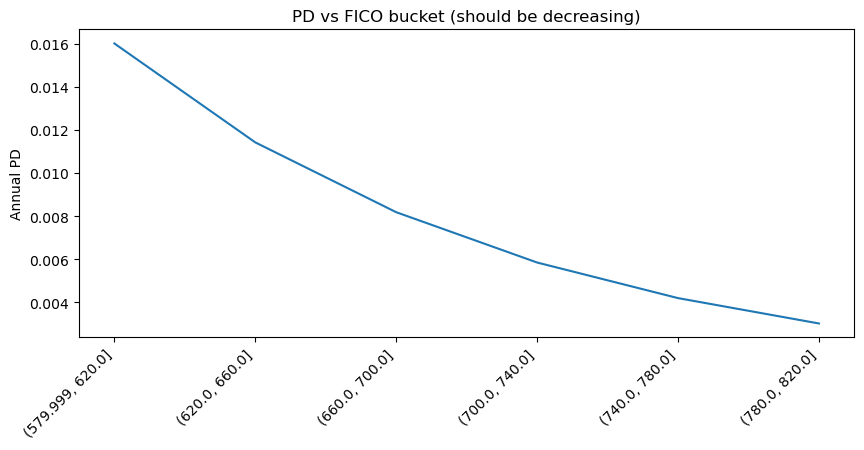

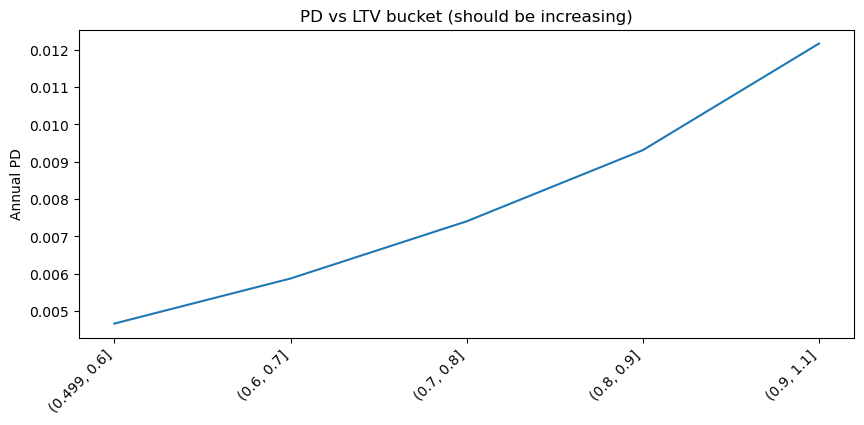

In [8]:
plt.figure(figsize=(10,4))
plt.plot(pd_by_fico["fico_bucket"].astype(str), pd_by_fico["pd_annual_mean"])
plt.title("PD vs FICO bucket (should be decreasing)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annual PD")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(pd_by_ltv["ltv_bucket"].astype(str), pd_by_ltv["pd_annual_mean"])
plt.title("PD vs LTV bucket (should be increasing)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annual PD")
plt.show()

In [9]:
issues = []

# DQ flags
for _, r in dq.iterrows():
    if bool(r["missing_flag"]):
        issues.append({"type":"DQ", "issue": r["column"], "detail": f"rate={r['missing_pct']:.3%}"})

# Monotonicity flags
if viol_fico > 0:
    issues.append({"type":"MODEL_SANITY", "issue":"PD vs FICO not monotone", "detail": f"violations={viol_fico}"})
if viol_ltv > 0:
    issues.append({"type":"MODEL_SANITY", "issue":"PD vs LTV not monotone", "detail": f"violations={viol_ltv}"})

# Drift flags
for _, r in drift.iterrows():
    if bool(r["drift_flag"]):
        issues.append({"type":"DRIFT", "issue": f"{r['metric']} drift", "detail": f"z={r['z_drift']:.2f}"})

issues_df = pd.DataFrame(issues).sort_values(["type","issue"]) if issues else pd.DataFrame(columns=["type","issue","detail"])
issues_df

,type,issue,detail


In [10]:
def export_review_pack(cfg: ReviewConfig,
                       dq: pd.DataFrame,
                       drift: pd.DataFrame,
                       issues: pd.DataFrame,
                       pd_by_fico: pd.DataFrame,
                       pd_by_ltv: pd.DataFrame):

    out = Path(cfg.out_dir)
    out.mkdir(parents=True, exist_ok=True)

    # Excel
    xlsx_path = out / f"{cfg.client_name}_model_review_{cfg.run_date}.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as w:
        dq.to_excel(w, sheet_name="DQ_Summary", index=False)
        drift.to_excel(w, sheet_name="Drift_Summary", index=False)
        issues.to_excel(w, sheet_name="Issues", index=False)
        pd_by_fico.to_excel(w, sheet_name="PD_by_FICO", index=False)
        pd_by_ltv.to_excel(w, sheet_name="PD_by_LTV", index=False)

    # HTML summary (simple, shareable)
    html_path = out / f"{cfg.client_name}_model_review_{cfg.run_date}.html"
    html = f"""
    <h1>Model Review Report</h1>
    <p><b>Client:</b> {cfg.client_name} | <b>Run date:</b> {cfg.run_date}</p>
    <h2>Issues</h2>
    {issues.to_html(index=False)}
    <h2>Data Quality</h2>
    {dq.to_html(index=False)}
    <h2>Drift</h2>
    {drift.to_html(index=False)}
    <h2>PD vs FICO</h2>
    {pd_by_fico.to_html(index=False)}
    <h2>PD vs LTV</h2>
    {pd_by_ltv.to_html(index=False)}
    """
    html_path.write_text(html, encoding="utf-8")

    # Save config used
    (out / f"{cfg.client_name}_config_{cfg.run_date}.json").write_text(
        json.dumps(asdict(cfg), indent=2), encoding="utf-8"
    )

    return str(xlsx_path), str(html_path)

xlsx_file, html_file = export_review_pack(cfg, dq, drift, issues_df, pd_by_fico, pd_by_ltv)
xlsx_file, html_file

('review_outputs\\DemoClient_model_review_2026-01-24.xlsx',
 'review_outputs\\DemoClient_model_review_2026-01-24.html')

In [11]:
from IPython.display import FileLink
FileLink(xlsx_file), FileLink(html_file)

(C:\Users\gtmlv\review_outputs\DemoClient_model_review_2026-01-24.xlsx,
 C:\Users\gtmlv\review_outputs\DemoClient_model_review_2026-01-24.html)

## Results & Interpretation

### Data Quality Results
The data quality checks do **not flag material issues**, indicating:
- model outputs are within reasonable bounds,
- no structural or technical errors are present.

**Interpretation:**  
The dataset is suitable for economic interpretation and downstream use.

---

### Credit Model Behaviour (Monotonicity Results)
The PD-by-FICO and PD-by-LTV diagnostics show:

- **PD decreases monotonically with FICO**
- **PD increases monotonically with LTV**
- No material reversals or instability across buckets

**Interpretation:**  
The credit model behaves consistently with economic intuition and regulatory expectations.
Borrower quality and leverage are reflected correctly in default risk.

---

### Drift Analysis Results
The drift analysis shows **no statistically significant deviations** between the current and prior runs
for key metrics such as CPR, PD, MDR, and LGD.

**Interpretation:**  
The model is stable over time, and there is no evidence of unintended recalibration, data leakage,
or regime breaks between runs.

---

### Issues Summary
The consolidated Issues table is empty (or contains no material flags).

**Interpretation:**  
There are no blocking concerns that would prevent the use of these model outputs for:
- pricing,
- risk aggregation,
- structured product valuation,
- or client delivery.

---

## Overall Takeaways

- Model outputs pass technical data-quality validation
- Credit risk behaves economically correctly across key drivers
- No material drift is detected across runs
- The model is suitable for production use under the reviewed assumptions

This notebook demonstrates how automated validation and monitoring can significantly reduce
model risk while improving transparency and governance.

---

## Conclusion

This model review framework provides a systematic and repeatable approach to validating
prepayment and credit model outputs before they are used in financial decision-making.
By combining data quality checks, economic sanity tests, and drift detection, the notebook
ensures that model results are **credible, explainable, and production-ready**.